In [ ]:
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from openquake.commonlib.datastore import read
import matplotlib.pyplot as plt

In [2]:
!oq engine --lrc

job_id |     status |          start_time |         description
     1 |   complete | 2024-11-03 12:06:15.308445 | Scenario Risk Demo (Catania Tsunami) using hysea simulation no aggregation
     2 |   complete | 2024-11-03 12:06:35.087976 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 892 no aggregation
     3 |   complete | 2024-11-03 12:06:54.806854 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 1658 no aggregation
     4 |   complete | 2024-11-03 12:07:16.469549 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 3454 no aggregation
     5 |   complete | 2024-11-03 12:12:18.075475 | Scenario Risk Demo (Catania Tsunami) using emulation results with training size 7071 no aggregation
     6 |   complete | 2024-11-03 13:17:53.362380 | Scenario Risk Demo (Catania Tsunami) using hysea simulation with foglio aggregation
     7 |   complete | 2024-11-03 13:19:15.386250 | Scenario Risk Demo (C

In [3]:
dstore = read(1)
list(dstore)

['agg_values',
 'assetcol',
 'avg_losses-rlzs',
 'crm',
 'discarded',
 'events',
 'exposure',
 'full_lt',
 'gmf_data',
 'oqparam',
 'performance_data',
 'risk_by_event',
 'rupgeoms',
 'ruptures',
 'sitecol',
 'task_info',
 'task_sent',
 'taxmap',
 'weights']

In [4]:
dstore.read_df('risk_by_event').head()
# dstore.close()

,event_id,agg_id,loss_id,variance,loss
0,53433,0,3,0.0,4.245314e+06
1,53434,0,3,0.0,8.007347e+05
2,53435,0,3,0.0,4.158568e+02
3,53436,0,3,0.0,7.612706e+06
4,53437,0,3,0.0,2.159918e+06


In [23]:
event_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_CT_38.csv',header=0)
event_info['event_id']= event_info.index

run_name = ['true','mean','sigmaminus','sigmaplus']

for i,job_id in enumerate([30,55,56,57]):
    print(f'Job {job_id} for {run_name[i]}')
    # Load the results
    dstore = read(job_id)

    # Extract the data
    data_event = dstore.read_df('risk_by_event')
    #aggregate the data based on event_id
    event_loss = data_event.groupby('event_id')['loss'].sum()

    #number of events
    print('Number of events:', len(event_loss))

    #save the data to a csv file
    event_loss.to_csv(f'1_event_only_loss_{run_name[i]}.csv', index=True)

    #append event_loss to event_info
    event_info = event_info.join(event_loss, on='event_id', rsuffix=f'_{run_name[i]}')

#rename column loss to loss_true
event_info.rename(columns={'loss':'loss_true'}, inplace=True)

#set missing values to 0
event_info[f'loss_true'] = event_info[f'loss_true'].fillna(0)
event_info[f'loss_mean'] = event_info[f'loss_mean'].fillna(0)
event_info[f'loss_sigmaminus'] = event_info[f'loss_sigmaminus'].fillna(0)
event_info[f'loss_sigmaplus'] = event_info[f'loss_sigmaplus'].fillna(0)

#save the data to a csv file
# event_info.to_csv('3_event_info_loss_uncertainty.csv', index=False)


Job 30 for true


Number of events: 43895
Job 55 for mean
Number of events: 53419
Job 56 for sigmaminus
Number of events: 36147
Job 57 for sigmaplus
Number of events: 53550


In [5]:
event_info = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_CT_38.csv',header=0)
event_info['event_id']= event_info.index

run_name = ['true','892','1658','3454','7071']

for i,job_id in enumerate([1,2,3,4,5]):
    print(f'Job {job_id} for {run_name[i]}')
    # Load the results
    dstore = read(job_id)

    # Extract the data
    data_event = dstore.read_df('risk_by_event')
    #aggregate the data based on event_id
    event_loss = data_event.groupby('event_id')['loss'].sum()

    #number of events
    print('Number of events:', len(event_loss))

    #save the data to a csv file
    event_loss.to_csv(f'1_event_only_loss_{run_name[i]}.csv', index=True)

    #append event_loss to event_info
    event_info = event_info.join(event_loss, on='event_id', rsuffix=f'_{run_name[i]}')

#rename column loss to loss_true
event_info.rename(columns={'loss':'loss_true'}, inplace=True)

#set missing values to 0
event_info[f'loss_true'] = event_info[f'loss_true'].fillna(0)
event_info[f'loss_892'] = event_info[f'loss_892'].fillna(0)
event_info[f'loss_1658'] = event_info[f'loss_1658'].fillna(0)
event_info[f'loss_3454'] = event_info[f'loss_3454'].fillna(0)
event_info[f'loss_7071'] = event_info[f'loss_7071'].fillna(0)

#save the data to a csv file
event_info.to_csv('3_event_info_loss.csv', index=False)


Job 1 for true
Number of events: 43895
Job 2 for 892
Number of events: 53519
Job 3 for 1658
Number of events: 53543
Job 4 for 3454
Number of events: 53475
Job 5 for 7071
Number of events: 53386


In [19]:
def get_loss_pml(loss,rate,threshold,PoE):

    total_value = 28491684200

    #filter events based on threshold of 500
    print('Number of events before filtering:', len(loss))
    rate = rate[loss>threshold]
    loss = loss[loss>threshold]
    print('Number of events after filtering:', len(loss))

    #reset index
    rate = rate.reset_index(drop=True)
    loss = loss.reset_index(drop=True)

    #sort descending
    idx = np.argsort(loss)[::-1]
    sorted_loss = loss[idx]
    sorted_rate = rate[idx]  
    

    #Event loss table
    ELT = pd.DataFrame({'loss':sorted_loss,'rate':sorted_rate})
    ELT['weighted_loss'] = sorted_loss*sorted_rate
    ELT['cumulative_probability'] = ELT['rate'].cumsum()

    AAL = np.sum(ELT['weighted_loss'])
    print('AAL:',AAL,'\n')

    PML = np.zeros(len(PoE))
    PML_ratio = np.zeros(len(PoE))
    #find the event loss for each RP
    for i,probability_level in enumerate(PoE):
        PML[i] = ELT['loss'][ELT['cumulative_probability']>probability_level].max()
        if PML[i] == np.nan:
            PML_ratio[i] = 0
        else:
            PML_ratio[i] = PML[i]/total_value

    return PML,PML_ratio,ELT

Number of events before filtering: 53550
Number of events after filtering: 31045
AAL: 20169.98929125544 

Number of events before filtering: 53550
Number of events after filtering: 29413
AAL: 14583.916819535421 

Number of events before filtering: 53550
Number of events after filtering: 32548
AAL: 18543.528277453188 

Number of events before filtering: 53550
Number of events after filtering: 30199
AAL: 15929.343952775502 

Number of events before filtering: 53550
Number of events after filtering: 30023
AAL: 16446.22560837401 



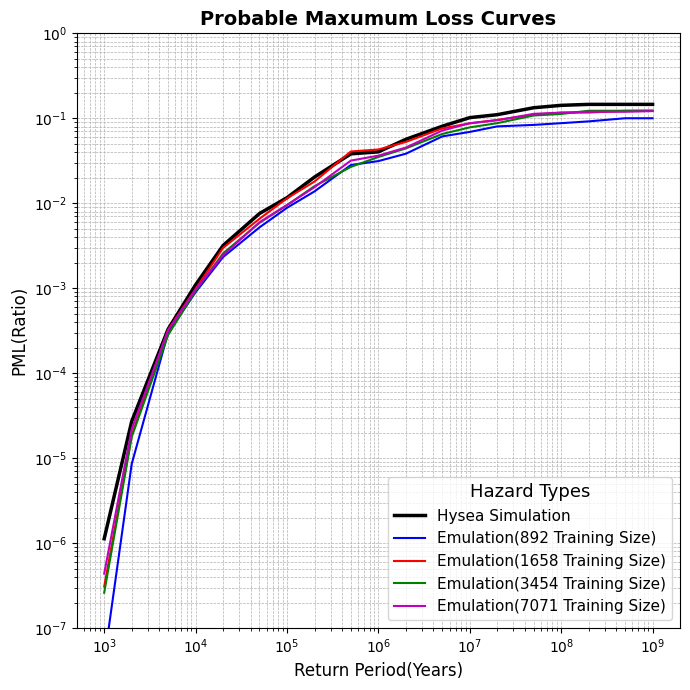

In [7]:
#get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
RP = [10, 20, 50,
      100, 200, 500, 
      1000, 2000, 5000,
      10000, 20000, 50000, 
      100000, 200000, 500000, 
      1000000, 2000000, 5000000, 
      10000000, 20000000, 50000000, 
      100000000, 200000000, 500000000, 1000000000]

PoE = [1/rp for rp in RP]

min_loss = 500

PML_true = get_loss_pml(event_info['loss_true'],event_info['mean_prob'],min_loss,PoE)[1]
PML_892 = get_loss_pml(event_info['loss_892'],event_info['mean_prob'],min_loss,PoE)[1]
PML_1658 = get_loss_pml(event_info['loss_1658'],event_info['mean_prob'],min_loss,PoE)[1]
PML_3454 = get_loss_pml(event_info['loss_3454'],event_info['mean_prob'],min_loss,PoE)[1]
PML_7071 = get_loss_pml(event_info['loss_7071'],event_info['mean_prob'],min_loss,PoE)[1]


#plot
fig, ax = plt.subplots(figsize=(7, 7))

# Use a professional color palette
colors = ['k', 'b', 'r', 'g', 'm']

ax.plot(RP, PML_true, label='Hysea Simulation', color=colors[0], linewidth=2.5)
ax.plot(RP, PML_892, label='Emulation(892 Training Size)', color=colors[1], linewidth=1.5)
ax.plot(RP, PML_1658, label='Emulation(1658 Training Size)', color=colors[2], linewidth=1.5)
ax.plot(RP, PML_3454, label='Emulation(3454 Training Size)', color=colors[3], linewidth=1.5)
ax.plot(RP, PML_7071, label='Emulation(7071 Training Size)', color=colors[4], linewidth=1.5)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Return Period(Years)', fontsize=12)
ax.set_ylabel('PML(Ratio)', fontsize=12)
ax.set_title('Probable Maxumum Loss Curves', fontsize=14, fontweight='bold')
ax.set_ylim(1e-7, 1e0)

# Add grid lines
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize legend
ax.legend(title='Hazard Types', title_fontsize='13', fontsize='11')

# Customize ticks
ax.tick_params(axis='both', which='major', labelsize=10)

# Show plot
plt.tight_layout()
plt.show()

Number of events before filtering: 53550
Number of events after filtering: 41445
AAL: 39035.20183799402 

Number of events before filtering: 53550
Number of events after filtering: 30130
AAL: 44821.255748820004 

Number of events before filtering: 53550
Number of events after filtering: 23203
AAL: 28382.415797768866 

Number of events before filtering: 53550
Number of events after filtering: 47292
AAL: 69694.0220248099 



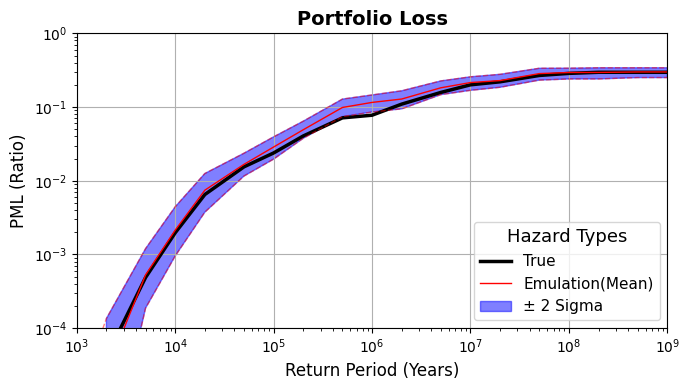

In [27]:
#get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
RP = [10, 20, 50,
      100, 200, 500, 
      1000, 2000, 5000,
      10000, 20000, 50000, 
      100000, 200000, 500000, 
      1000000, 2000000, 5000000, 
      10000000, 20000000, 50000000, 
      100000000, 200000000, 500000000, 1000000000]

PoE = [1/rp for rp in RP]

min_loss = 500

PML_true = get_loss_pml(event_info['loss_true'],event_info['mean_prob'],min_loss,PoE)[1]
PML_mean = get_loss_pml(event_info['loss_mean'],event_info['mean_prob'],min_loss,PoE)[1]
PML_sigmaminus = get_loss_pml(event_info['loss_sigmaminus'],event_info['mean_prob'],min_loss,PoE)[1]
PML_sigmaplus = get_loss_pml(event_info['loss_sigmaplus'],event_info['mean_prob'],min_loss,PoE)[1]

# plot
fig, ax = plt.subplots(figsize=(7, 4))

# Colors
color_true = 'k'
color_mean = 'b'
color_fill = 'b'
color_sigma = 'r'

# Plot the true simulation
ax.plot(RP, PML_true, label='True', color=color_true, linewidth=2.5)

# Plot the mean emulation as solid line
ax.plot(RP, PML_mean, label='Emulation(Mean)', color=color_sigma, linewidth=1,alpha=1)
ax.plot(RP, PML_sigmaminus, color=color_sigma, linewidth=1,alpha=0.5, linestyle='--')
ax.plot(RP, PML_sigmaplus, color=color_sigma, linewidth=1,alpha=0.5, linestyle='--')

# Fill between sigma minus and sigma plus
ax.fill_between(RP, PML_sigmaminus, PML_sigmaplus, color=color_fill, alpha=0.5, label='± 2 Sigma')

# Log scales
ax.set_xscale('log')
ax.set_yscale('log')

# Labels and title
ax.set_xlabel('Return Period (Years)', fontsize=12)
ax.set_ylabel('PML (Ratio)', fontsize=12)
ax.set_title('Portfolio Loss', fontsize=14, fontweight='bold')

# Limits
ax.set_ylim(1e-4, 1e0)
ax.set_xlim(1e3, 1e9)
ax.grid()

# Grid
# ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Legend
ax.legend(title='Hazard Types', title_fontsize=13, fontsize=11)

# Ticks
ax.tick_params(axis='both', which='major', labelsize=10)

# Layout and show
plt.tight_layout()
# plt.show()
# plt.savefig('portfolio_loss.png', dpi=300, bbox_inches='tight',transparent=True)

In [4]:
RP = []

# Every 10 from 10 to 90
# RP.extend(range(10, 100, 10))

# Increasing by powers of 10
for exp in range(2, 10):  # 10^2 = 100 to 10^9 = 1,000,000,000
    step = 10 ** (exp - 1)
    RP.extend(range(10**exp, 10**(exp + 1), step))

print(RP)

[100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400, 410, 420, 430, 440, 450, 460, 470, 480, 490, 500, 510, 520, 530, 540, 550, 560, 570, 580, 590, 600, 610, 620, 630, 640, 650, 660, 670, 680, 690, 700, 710, 720, 730, 740, 750, 760, 770, 780, 790, 800, 810, 820, 830, 840, 850, 860, 870, 880, 890, 900, 910, 920, 930, 940, 950, 960, 970, 980, 990, 1000, 1100, 1200, 1300, 1400, 1500, 1600, 1700, 1800, 1900, 2000, 2100, 2200, 2300, 2400, 2500, 2600, 2700, 2800, 2900, 3000, 3100, 3200, 3300, 3400, 3500, 3600, 3700, 3800, 3900, 4000, 4100, 4200, 4300, 4400, 4500, 4600, 4700, 4800, 4900, 5000, 5100, 5200, 5300, 5400, 5500, 5600, 5700, 5800, 5900, 6000, 6100, 6200, 6300, 6400, 6500, 6600, 6700, 6800, 6900, 7000, 7100, 7200, 7300, 7400, 7500, 7600, 7700, 7800, 7900, 8000, 8100, 8200, 8300, 8400, 8500, 8600, 8700, 8800, 8900, 9000, 9100, 9200, 9300, 9400, 9500, 9600, 9700, 9800, 9900, 10000, 11

Number of events before filtering: 53550
Number of events after filtering: 31045
AAL: 20169.989239660295 

Number of events before filtering: 53550
Number of events after filtering: 30130
AAL: 44821.255748820004 

Number of events before filtering: 53550
Number of events after filtering: 31045
AAL: 20169.989239660295 



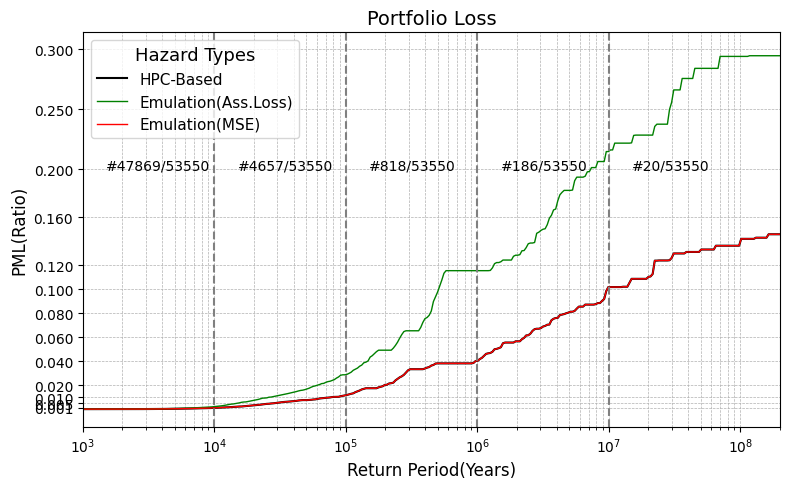

In [25]:
#read event_info
# event_info = pd.read_csv('3_event_info_loss_uncertainty.csv')
event_info_old = pd.read_csv('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/risk/results/3_event_info_agg_loss.csv')

#get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
# RP = [10, 20, 50,
#       100, 200, 500, 
#       1000, 2000, 5000,
#       10000, 20000, 50000, 
#       100000, 200000, 500000, 
#       1000000, 2000000, 5000000, 
#       10000000, 20000000, 50000000, 
#       100000000, 200000000, 500000000, 1000000000]

PoE = [1/rp for rp in RP]

# def get_loss_pml(loss,rate,threshold,PoE,total_value = 28491684200,t = [1e-4,1e-6,1e-8]):
    
#     #filter events based on threshold of 500
#     # print('Number of events before filtering:', len(loss))
#     rate = rate[loss>threshold]
#     loss = loss[loss>threshold]
#     # print('Number of events after filtering:', len(loss))

#     #reset index
#     rate = rate.reset_index(drop=True)
#     loss = loss.reset_index(drop=True)

#     #sort descending
#     idx = np.argsort(loss)[::-1]
#     sorted_loss = loss[idx]
#     sorted_rate = rate[idx]  
    
#     #Event loss table
#     ELT = pd.DataFrame({'loss':sorted_loss,'rate':sorted_rate})
#     ELT['weighted_loss'] = sorted_loss*sorted_rate
#     ELT['cumulative_probability'] = ELT['rate'].cumsum()

#     AAL = np.sum(ELT['weighted_loss'])
#     print('AAL:',AAL,'\n')

#     PML = np.zeros(len(PoE))
#     PML_ratio = np.zeros(len(PoE))

#     if total_value ==  28491684200:
#         print('Warning, using default portfolio exposure value of 2.8e10')

#     #find the event loss for each RP
#     for i,probability_level in enumerate(PoE):
#         # print(probability_level,len(ELT['loss'][ELT['cumulative_probability']>probability_level]))
#         PML[i] = ELT['loss'][ELT['cumulative_probability']>probability_level].max()
#         if PML[i] == np.nan:
#             PML_ratio[i] = 0
#         else:
#             PML_ratio[i] = PML[i]/total_value

#     #get count of events exceeding threshold probability t 
#     ncount = []
#     for i,prob in enumerate(t):
#         neve = len(ELT['loss'][ELT['cumulative_probability']<prob])
#         ncount.append(neve)     
#     return PML,PML_ratio,ELT,AAL,ncount



# Define Return Periods and corresponding PoEs
RP = np.logspace(1, 9, num=500, base=10)  # Smooth log-scaled RP
PoE = [1/rp for rp in RP]

# Set minimum loss threshold
min_loss = 500

# Compute PML values
PML_true = get_loss_pml(event_info_old['loss_true'], event_info_old['mean_prob'], min_loss, PoE)[1]
PML_mean = get_loss_pml(event_info['loss_mean'], event_info['mean_prob'], min_loss, PoE)[1]
PML_old = get_loss_pml(event_info_old['loss_true'],event_info_old['mean_prob'],min_loss,PoE)[1]

#plot
fig, ax = plt.subplots(figsize=(8, 5))
# Plot true PML
#remove some repetitive rows from RP and PML_true based on unique values in PML_true
ax.plot(RP, PML_true, label='HPC-Based', color='k', linewidth=1.5)

# Plot emulated mean and old
ax.plot(RP, PML_mean, label='Emulation(Ass.Loss)', color='g', linewidth=1)
ax.plot(RP, PML_old, label='Emulation(MSE)', color='r', linewidth=1)


# Total value (for event count annotations)
total_value = 28491684200
thresholds = [1e-4, 1e-5, 1e-6, 1e-7, 1e-8]
# ncount = get_loss_pml(event_info['loss_true'], event_info['mean_prob'], min_loss, PoE, total_value, thresholds)[-1]

# Annotate event counts
ax.text(1.5*(1e3),0.2, '#'+str(event_info.shape[0]-ncount[0])+'/'+str(event_info.shape[0]), color='k')
ax.text(1.5*(1e4),.2, '#'+str(ncount[0]-ncount[1])+'/'+str(event_info.shape[0]), color='k')
ax.text(1.5*(1e5),.2, '#'+str(ncount[1]-ncount[2])+'/'+str(event_info.shape[0]), color='k')
ax.text(1.5*(1e6),.2, '#'+str(ncount[2]-ncount[3])+'/'+str(event_info.shape[0]), color='k')
ax.text(1.5*(1e7),.2, '#'+str(ncount[3])+'/'+str(event_info.shape[0]), color='k')

#draw vertical line exceed threshold probability of 1e4, 1e6, 1e8
ax.axvline(x=1e4, color='grey', linestyle='--')
ax.axvline(x=1e5, color='grey', linestyle='--')
ax.axvline(x=1e6, color='grey', linestyle='--')
ax.axvline(x=1e7, color='grey', linestyle='--')


ax.set_xscale('log')
# ax.set_yscale('log')
ax.set_xlabel('Return Period(Years)', fontsize=12)
ax.set_ylabel('PML(Ratio)', fontsize=12)
ax.set_title('Portfolio Loss', fontsize=14)
ax.set_xlim(1e3, 2e8)
# ax.set_ylim(1e-5, 2e-1)
ax.set_yticks([0.001, 0.005, 0.01, 0.02, 0.04,.06,.08,.1,.12,.16,.20,.25,.3]) 
# Add grid lines
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize legend
ax.legend(title='Hazard Types', title_fontsize='13', fontsize='11')

# Customize ticks
ax.tick_params(axis='both', which='major', labelsize=10)

# Show plot
plt.tight_layout()
plt.show()


In [ ]:
#get probability of exceedance thresholds using RPs from 1 in 10 to 1 in 10e8
RP = np.logspace(1, 9, num=500, base=10)
PoE = [1/rp for rp in RP]
min_loss = 500

#merge event_info with rates 
event_info = pd.read_csv(f'{MLDir}/risk/results/3_event_info_agg_loss.csv',header=0)
rates = pd.read_csv(f'{MLDir}/resources/processed/all_eventsBS_PS53550_perce_rates.txt')
#rename column from ID to eve_id
rates = rates.rename(columns={'ID':'eve_id'})
event_info = pd.merge(event_info,rates,on='eve_id',how='inner')

#True PML
PML_05 = get_loss_pml(event_info['loss_true'],event_info['P05'],min_loss,PoE)[1]
PML_16 = get_loss_pml(event_info['loss_true'],event_info['P16'],min_loss,PoE)[1]
PML_50 = get_loss_pml(event_info['loss_true'],event_info['P50'],min_loss,PoE)[1]
PML_84 = get_loss_pml(event_info['loss_true'],event_info['P84'],min_loss,PoE)[1]
PML_95 = get_loss_pml(event_info['loss_true'],event_info['P95'],min_loss,PoE)[1]
PML_mean = get_loss_pml(event_info['loss_true'],event_info['Pmean'],min_loss,PoE)[1]

#Emulation PML
PML_05_E = get_loss_pml(event_info['loss_1658'],event_info['P05'],min_loss,PoE)[1]
PML_16_E = get_loss_pml(event_info['loss_1658'],event_info['P16'],min_loss,PoE)[1]
PML_50_E = get_loss_pml(event_info['loss_1658'],event_info['P50'],min_loss,PoE)[1]
PML_84_E = get_loss_pml(event_info['loss_1658'],event_info['P84'],min_loss,PoE)[1]
PML_95_E = get_loss_pml(event_info['loss_1658'],event_info['P95'],min_loss,PoE)[1]
PML_mean_E = get_loss_pml(event_info['loss_1658'],event_info['Pmean'],min_loss,PoE)[1]

#compute relative error for each threshold of return period between predictions and true
rel_error_05 = (PML_05 - PML_05_E)/PML_05
rel_error_16 = (PML_16 - PML_16_E)/PML_16
rel_error_50 = (PML_50 - PML_50_E)/PML_50
rel_error_84 = (PML_84 - PML_84_E)/PML_84
rel_error_95 = (PML_95 - PML_95_E)/PML_95
rel_error_mean = (PML_mean - PML_mean_E)/PML_mean

#plot
fig, ax = plt.subplots(figsize=(8, 5))

# Use a professional color palette percentiles(0.05,0.16,0.5,0.84,0.95), mean
colors = ['k', 'g' ]
lines = ['-', ':','--']

#Emulation
ax.plot(RP, PML_mean_E, label='Emulation(Mean)', color='g', linewidth=1.0,linestyle=lines[0])
# ax.plot(RP, PML_84_E, label='Emulation(84%)', color=colors[1], linewidth=1.0,linestyle=lines[1])
# ax.plot(RP, PML_95_E, label='Emulation(95%)', color=colors[1], linewidth=1.0,linestyle=lines[2])
#True
ax.plot(RP, PML_mean, label='HPC(Mean)', color='r', linewidth=1.0,linestyle=lines[0])
ax.plot(RP, PML_05, label='HPC(P05)', color=colors[0], linewidth=1.0,linestyle=lines[1])
ax.plot(RP, PML_16, label='HPC(P16)', color=colors[0], linewidth=1.0,linestyle=lines[2])
ax.plot(RP, PML_50, label='HPC(P50)', color=colors[0], linewidth=1.0,linestyle=lines[0])
ax.plot(RP, PML_84, label='HPC(P84)', color=colors[0], linewidth=1.0,linestyle=lines[2])
ax.plot(RP, PML_95, label='HPC(P95)', color=colors[0], linewidth=1.0,linestyle=lines[1])



#get nevents exceeding threshold probability of 1e-4, 1e-6, 1e-8 depths
total_value = 28491684200
t = [1e-4,1e-5,1e-6,1e-7,1e-8]
ncount = get_loss_pml(event_info['loss_true'],event_info['mean_prob'],min_loss,PoE,total_value,t)[-1]
# #get counts of events exceeding threshold probability of 1e-4, 1e-6, 1e-8
# ax.text(1.5*(1e3),0.14, '#'+str(event_info.shape[0]-ncount[0])+'/'+str(event_info.shape[0]), color='k')
# ax.text(1.5*(1e4),.14, '#'+str(ncount[0]-ncount[1])+'/'+str(event_info.shape[0]), color='k')
# ax.text(1.5*(1e5),.14, '#'+str(ncount[1]-ncount[2])+'/'+str(event_info.shape[0]), color='k')
# ax.text(1.5*(1e6),.14, '#'+str(ncount[2]-ncount[3])+'/'+str(event_info.shape[0]), color='k')
# ax.text(1.5*(1e7),.14, '#'+str(ncount[3])+'/'+str(event_info.shape[0]), color='k')

#draw vertical line exceed threshold probability of 1e4, 1e6, 1e8
# ax.axvline(x=1e4, color='grey', linestyle='--')
# ax.axvline(x=1e5, color='grey', linestyle='--')
# ax.axvline(x=1e6, color='grey', linestyle='--')
# ax.axvline(x=1e7, color='grey', linestyle='--')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Return Period(Years)', fontsize=12)
ax.set_ylabel('PML(Ratio)', fontsize=12)
ax.set_title('Portfolio Loss', fontsize=14)
ax.set_xlim(1e2, 1e9)
ax.set_ylim(1e-4, 2e-1)
# ax.set_yticks([0.0001, 0.0005,0.001, 0.005, 0.01, 0.02, 0.04,.06,.08,.1,]) 
# Add grid lines
ax.grid(True, which='both', linestyle='--', linewidth=0.5)

# Customize legend
ax.legend(title='Hazard Types', title_fontsize='13', fontsize='11',ncol=1)

# Customize ticks
ax.tick_params(axis='both', which='major', labelsize=10)

# Show plot
plt.tight_layout()
plt.savefig(f'{MLDir}/risk/plots/risk_compare/PML_portfolio_uncertainity.png')
plt.show()

# #plot exceedance curve
# plt.figure(figsize=(5, 5))
# plt.plot(rel_error_mean,PoE, label='Emul. Error(mean)', color='k',linewidth=1,linestyle=lines[0])
# plt.plot(rel_error_84,PoE, label='Emul. Error(84%)', color='r',linewidth=1,linestyle=lines[1])
# plt.plot(rel_error_95,PoE, label='Emul. Error(95%)', color='b',linewidth=1,linestyle=lines[2])
# plt.axvline(0, color='black', linestyle='--', linewidth=1)
# plt.ylabel('Probability of Exceedance')
# plt.xlabel('Relative Error')
# plt.yscale('log')
# plt.grid(True)
# plt.xlim(-1, 1)
# plt.ylim(1e-8,1e-2)
# plt.legend(ncol=1)
# plt.title(f'Portfolio Loss')
# plt.savefig(f'{MLDir}/risk/plots/risk_compare/risk_rel_err_portfolio_uncertainity.png')
# plt.show()

